In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay, confusion_matrix, f1_score, roc_curve, auc
from sklearn.model_selection import cross_val_score, train_test_split, RandomizedSearchCV, RepeatedKFold, GridSearchCV
from sklearn.inspection import permutation_importance

**Loading in the Training Data**

In [16]:
# loads the training data into a dataframe
train_df = pd.read_csv("train_set.csv")
train_df.head()

,pH,Turbidity,Total Phosphorus (TP),Specific Conductance (Field),Water Temperature (Field),Total Suspended Solids (TSS),Nitrate (NO3-N),Ammonia (NH3-N),True Color,Total Organic Carbon (TOC),...,Potassium (K)(Dissolved),Sodium (Na)(Dissolved),Magnesium (Mg)(Dissolved),Calcium (Ca)(Dissolved),Sodium Adsorption Ratio (SAR)(Calculated),Dissolved Oxygen (Field),Total Kjeldahl Nitrogen (TKN),Hardness,Fluoride (F),contaminated
0,8.40,1.20,0.00200,333.031,11.10394,2.000,0.11000,0.0500,3.300,1.400,...,0.600,3.200,14.400,45.400,0.5900,9.9555,0.10000,173.00,0.1200,0
1,8.50,0.81,0.00400,339.000,4.00000,0.500,0.05400,0.0400,7.500,4.400,...,1.700,11.800,19.600,68.100,1.7800,11.8000,0.25969,247.68,0.1100,1
2,8.23,2.10,0.00585,388.720,7.25215,2.989,0.05391,0.0528,3.073,1.383,...,0.838,6.329,15.938,55.062,1.0542,10.7856,0.13448,203.33,0.2708,0
3,8.10,1.21,0.00400,465.600,2.00000,0.500,0.18000,0.0400,1.000,0.900,...,1.000,6.600,19.000,62.000,1.0400,11.8000,0.11600,252.00,0.2700,0
4,8.20,0.33,0.00200,466.600,0.20000,2.000,0.08000,0.0500,2.000,1.700,...,1.500,12.600,18.100,59.900,2.0200,11.8900,0.10000,224.00,0.1000,0


In [17]:
# splits the training data into X for predictor variables and y for target variable
y_train = train_df['contaminated']
X_train = train_df.drop(columns=['contaminated'])

**Hyperparameter Tuning**
We will begin the process of hyperparameter tuning with a random search. This random search will be conducted over a wide hyperparameter space. With the random search, we will identify ranges for the most promising hyperparameter values. We will then conduct a grid search on the more narrow hyperparameter space identified by the random search.

In [18]:
# defines a grid of parameters to be searched by random search
parameters = {'n_estimators': list(range(100, 501)), 'max_features': ['sqrt', 'log2', None], 'max_depth': [10, 20, 30, 40, None], 'min_samples_leaf': list(range(1, 11))}

# defines the random forest model
forest = RandomForestClassifier(class_weight = "balanced", random_state = 42)

In [19]:
# defines a random search on the parameter grid to find the optimal hyperparameters
search = RandomizedSearchCV(
    forest,
    parameters,
    n_iter = 100,
    scoring="f1",
    n_jobs = -1,
    random_state = 42
)

In [20]:
# conducts the random search on the train set
search.fit(X_train, y_train)
# print the results of the random search to a dataframe
results = pd.DataFrame(search.cv_results_)
#results.head()

In [21]:
# sorts the results of the random search by test rank
results = results.sort_values(by='rank_test_score')
results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_min_samples_leaf,param_max_features,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
15,4.880434,0.090558,0.071595,0.003177,288,3,log2,40,"{'n_estimators': 288, 'min_samples_leaf': 3, '...",0.817460,0.834117,0.795558,0.811271,0.816460,0.814973,0.012373,1
69,3.363937,0.027157,0.051580,0.006352,134,2,sqrt,None,"{'n_estimators': 134, 'min_samples_leaf': 2, '...",0.808989,0.837802,0.796357,0.816623,0.814717,0.814897,0.013463,2
85,3.475316,0.043070,0.053846,0.004826,163,3,log2,None,"{'n_estimators': 163, 'min_samples_leaf': 3, '...",0.818302,0.838019,0.795291,0.809961,0.812827,0.814880,0.013851,3
98,9.480067,0.142049,0.159207,0.027525,397,1,log2,40,"{'n_estimators': 397, 'min_samples_leaf': 1, '...",0.817518,0.834455,0.793943,0.812954,0.811308,0.814036,0.012972,4
97,7.331496,0.051790,0.118327,0.004842,355,3,log2,30,"{'n_estimators': 355, 'min_samples_leaf': 3, '...",0.814276,0.832215,0.797907,0.811024,0.814136,0.813912,0.010951,5
10,21.089463,0.411408,0.378803,0.097496,402,3,sqrt,40,"{'n_estimators': 402, 'min_samples_leaf': 3, '...",0.811881,0.838019,0.796345,0.810243,0.813029,0.813903,0.013477,6
30,4.135041,0.064968,0.055079,0.003026,231,4,log2,40,"{'n_estimators': 231, 'min_samples_leaf': 4, '...",0.811271,0.839309,0.795055,0.809711,0.813559,0.813781,0.014320,7
71,9.014871,0.110174,0.144846,0.015400,417,3,log2,20,"{'n_estimators': 417, 'min_samples_leaf': 3, '...",0.814030,0.832440,0.794233,0.813115,0.814912,0.813746,0.012100,8
92,7.068436,0.067944,0.107582,0.008718,273,3,sqrt,40,"{'n_estimators': 273, 'min_samples_leaf': 3, '...",0.815303,0.836120,0.796345,0.807087,0.813316,0.813634,0.013041,9
73,4.157142,0.045758,0.065839,0.006416,192,3,log2,40,"{'n_estimators': 192, 'min_samples_leaf': 3, '...",0.816138,0.833780,0.795306,0.808650,0.813604,0.813496,0.012432,10


In [22]:
# defines a refined grid of parameters (based on results from random search) to be searched by grid search
refined_parameters = {'n_estimators': [200, 300, 400], 'min_samples_leaf': [1, 2, 3], 'max_features': ['sqrt', 'log2'], 'max_depth': [40, None]}

In [23]:
# defines a grid search on the refined parameters grid to find the optimal hyperparameters
gird_search = GridSearchCV(
    forest,
    refined_parameters,
    scoring="f1",
    n_jobs = -1,
)

In [24]:
# conducts the grid search on the train set
gird_search.fit(X_train, y_train)
# prints the results of the grid search to a dataframe
grid_results = pd.DataFrame(gird_search.cv_results_)
#grid_results.head()

In [25]:
# sorts the results of the grid search by test rank
grid_results = grid_results.sort_values(by='rank_test_score')
grid_results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_features,param_min_samples_leaf,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
3,5.316560,0.081178,0.074601,0.009098,40,sqrt,2,200,"{'max_depth': 40, 'max_features': 'sqrt', 'min...",0.816380,0.836680,0.800260,0.814474,0.816273,0.816813,0.011616,1
21,5.186210,0.059421,0.069556,0.005923,None,sqrt,2,200,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.816380,0.836680,0.800260,0.814474,0.816273,0.816813,0.011616,1
22,7.641493,0.036480,0.094287,0.006471,None,sqrt,2,300,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.816435,0.831989,0.796091,0.813115,0.815496,0.814625,0.011413,3
4,7.943601,0.053836,0.106521,0.008501,40,sqrt,2,300,"{'max_depth': 40, 'max_features': 'sqrt', 'min...",0.816435,0.831989,0.796091,0.813115,0.815496,0.814625,0.011413,3
17,8.703000,0.075822,0.127845,0.008419,40,log2,3,400,"{'max_depth': 40, 'max_features': 'log2', 'min...",0.813984,0.834117,0.795812,0.810243,0.816993,0.814230,0.012315,5
35,7.910511,0.051134,0.117745,0.014301,None,log2,3,400,"{'max_depth': None, 'max_features': 'log2', 'm...",0.813984,0.834117,0.795812,0.810243,0.816993,0.814230,0.012315,5
5,10.573764,0.087344,0.147152,0.014449,40,sqrt,2,400,"{'max_depth': 40, 'max_features': 'sqrt', 'min...",0.815894,0.834899,0.793238,0.812089,0.814961,0.814216,0.013235,7
23,10.071090,0.051991,0.118619,0.007477,None,sqrt,2,400,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.815894,0.834899,0.793238,0.812089,0.814961,0.814216,0.013235,7
29,10.145188,0.065157,0.184969,0.058368,None,log2,1,400,"{'max_depth': None, 'max_features': 'log2', 'm...",0.816733,0.833670,0.794737,0.813492,0.811308,0.813988,0.012433,9
11,9.921293,0.092527,0.192516,0.013032,40,log2,1,400,"{'max_depth': 40, 'max_features': 'log2', 'min...",0.816733,0.833670,0.794737,0.813492,0.811308,0.813988,0.012433,9


**Training the Random Forest Model**
We will now train the random forest model on the train set with the optimal hyperparameters identified by the grid search.

In [26]:
# trains a random forest model with the optimal hyperparameters from the grid search
tuned_forest = RandomForestClassifier(class_weight = "balanced", max_depth = 40, max_features = 'sqrt', min_samples_leaf = 2, n_estimators = 200, random_state = 42)
tuned_forest.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,40
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**Loading in the Test Data**

In [27]:
# loads the test data into a dataframe
test_df = pd.read_csv("test_set.csv")
test_df.head()

,pH,Turbidity,Total Phosphorus (TP),Specific Conductance (Field),Water Temperature (Field),Total Suspended Solids (TSS),Nitrate (NO3-N),Ammonia (NH3-N),True Color,Total Organic Carbon (TOC),...,Potassium (K)(Dissolved),Sodium (Na)(Dissolved),Magnesium (Mg)(Dissolved),Calcium (Ca)(Dissolved),Sodium Adsorption Ratio (SAR)(Calculated),Dissolved Oxygen (Field),Total Kjeldahl Nitrogen (TKN),Hardness,Fluoride (F),contaminated
0,8.2,0.40,0.00300,429.4,0.5,1.2,0.113000,0.0200,1.000,0.600,...,1.230,19.526,18.718,58.637,3.1177,12.7000,0.13268,228.05,0.2651,0
1,8.3,7.98,0.02600,413.0,7.3,19.2,0.080820,0.0523,8.200,1.000,...,1.229,12.601,16.944,57.003,2.0733,10.6923,0.20094,213.00,0.2667,1
2,7.6,686.73,0.40000,2920.0,-1.8,570.0,0.701591,0.5000,52.435,14.845,...,21.900,580.700,161.900,211.600,42.5000,5.1461,3.16038,530.20,0.4305,0
3,8.3,0.88,0.00400,415.4,3.0,4.4,0.096000,0.0400,2.400,1.200,...,0.800,3.700,17.000,61.000,0.5900,12.3000,0.09500,218.00,0.2200,0
4,7.8,0.76,0.00689,451.2,0.6,0.5,0.096750,0.0386,1.000,2.700,...,2.039,22.061,21.834,68.091,3.3652,9.3000,0.22707,260.99,0.2248,0


In [28]:
# splits the test data into X for predictor variables and y for target variable
y_test = test_df['contaminated']
X_test = test_df.drop(columns=['contaminated'])

**Making Predictions and Model Evaluation**
Now that we have trained the random forest model, we will use the model to make predictions on the test set. We will then evaluate the model by calculating the metrics for accuracy, recall, precision, and f1.

In [29]:
# uses the tuned random forest model to make predictions on the test set
y_pred = tuned_forest.predict(X_test)
# calculates and prints the accuracy, recall, precision, and F1 score of the predictions
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("F1 Score:", f1)

Accuracy: 0.8458106098165592
Recall: 0.8326315789473684
Precision: 0.83881230116649
F1 Score: 0.8357105124141574


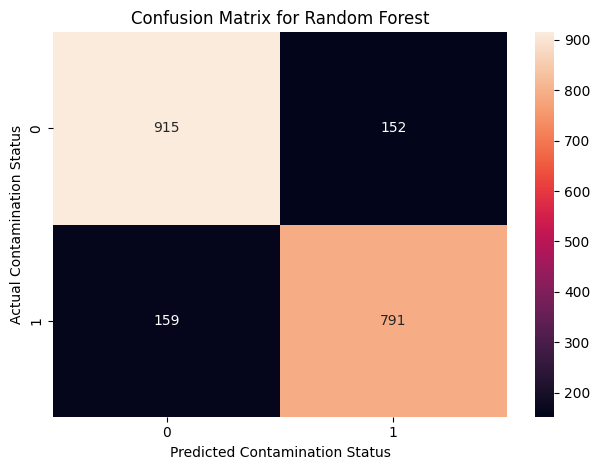

In [30]:
# creates a confusion matrix of predicted water status vs actual water status
cm = confusion_matrix(y_test, y_pred)

# get the unique scores and sort them for the labels
labels = sorted(y_test.unique())

# displays the confusion matrix as a heatmap with integer formatting (fmt='d')
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix for Random Forest')
plt.xlabel('Predicted Contamination Status')
plt.ylabel('Actual Contamination Status')
plt.tight_layout()
plt.savefig('confusion_matrix_random_forest.png')
plt.show()

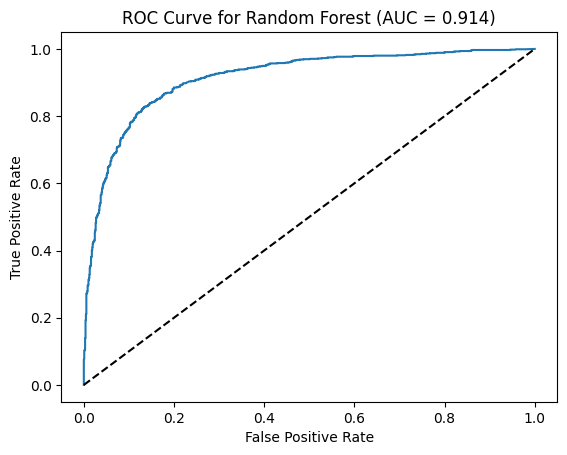

In [31]:
y_prob = tuned_forest.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve for Random Forest (AUC = {roc_auc:.3f})")
plt.savefig('roc_curve_random_forest.png')
plt.show()

**Feature Importances**
Now that we have our final random forest model, we can calculate the permutation importances for each feature. This tells us how important each feature is to the predictive ability of the model.

In [32]:
# calculates permutation importance
perm_result = permutation_importance(tuned_forest, X=X_test, y=y_test, scoring='f1', n_repeats=30, random_state = 42)

In [33]:
# creates a dataframe of permuation importances
perm_imp_df = pd.DataFrame({'feature': X_test.columns, 'importance': perm_result.importances_mean.round(4)})
perm_imp_df = perm_imp_df.sort_values(by='importance', ascending=False)
top10_perm_imp_df =perm_imp_df.head(10)
top10_perm_imp_df

,feature,importance
4,Water Temperature (Field),0.0850
2,Total Phosphorus (TP),0.0124
6,Nitrate (NO3-N),0.0114
11,NOx (Calculated),0.0090
21,Dissolved Oxygen (Field),0.0087
10,Total Dissolved Phosphorus (TDP),0.0075
5,Total Suspended Solids (TSS),0.0072
1,Turbidity,0.0067
14,Total Alkalinity,0.0056
13,Sulphate (SO4),0.0054


C:\Users\kkohl\AppData\Local\Temp\ipykernel_24928\1123163539.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top10_perm_imp_df['feature'] = top10_perm_imp_df['feature'].map(feature_name_map)


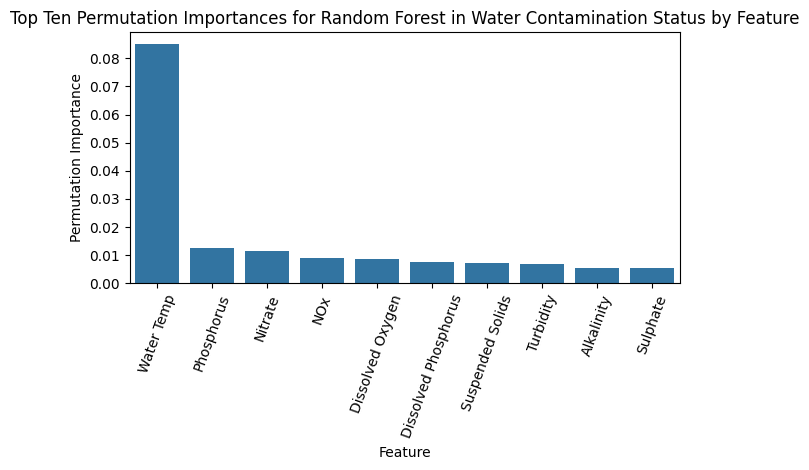

In [34]:
# create a dictionary to map current variable names to shorter names
feature_name_map = {
    'Water Temperature (Field)': 'Water Temp',
    'Total Phosphorus (TP)': 'Phosphorus',
    'Dissolved Oxygen (Field)': 'Dissolved Oxygen',
    'Nitrate (NO3-N)': 'Nitrate',
    'Daily Steps': 'Daily Steps',
    'Chloride (Cl)': 'Chloride',
    'NOx (Calculated)': 'NOx',
    'Total Suspended Solids (TSS)': 'Suspended Solids',
    'Turbidity': 'Turbidity',
    'Sodium Adsorption Ratio (SAR)(Calculated)': 'Sodium Adsorption',
    'Potassium (K)(Dissolved)': 'Potassium',
    "Total Alkalinity": "Alkalinity",
    "True Color": "True Color",
    "Total Dissolved Phosphorus (TDP)": "Dissolved Phosphorus",
    "Sulphate (SO4)": "Sulphate"
}

# updates the 'feature' column with the shorter names
top10_perm_imp_df['feature'] = top10_perm_imp_df['feature'].map(feature_name_map)

# create a barplot with the permutation importance by feature
sns.barplot(data = top10_perm_imp_df, x='feature', y='importance').set(xlabel = "Feature", ylabel = "Permutation Importance")
plt.xticks(rotation=70)
plt.title("Top Ten Permutation Importances for Random Forest in Water Contamination Status by Feature")
plt.savefig('permutation_importance_random_forest.png', bbox_inches='tight')
plt.tight_layout()